# Kalman Filter on AIS Data

This notebook runs a linear Kalman Filter on AIS position measurements.

Diagnostics included:
- Innovation logging
- Normalized Innovation Squared (NIS)
- Innovation magnitude plot
- NIS consistency check


## Load AIS Data
Ensure `positions` and `dt` are available.

positions shape should be (N,2):
[x_position, y_position]

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load AIS CSV
df = pd.read_csv("Data/AIS_2016_11_22.csv")

# Convert timestamps
df["BaseDateTime"] = pd.to_datetime(df["BaseDateTime"])

# Sort chronologically
df = df.sort_values("BaseDateTime").reset_index(drop=True)

# ---- Limit dataset to first 1000 points ----
df = df.iloc[:1000]

# Extract coordinates
lat = df["LAT"].values
lon = df["LON"].values

In [16]:
R_earth = 6371000  # meters

lat0 = np.deg2rad(lat[0])
lon0 = np.deg2rad(lon[0])

lat_rad = np.deg2rad(lat)
lon_rad = np.deg2rad(lon)

x = R_earth * (lon_rad - lon0) * np.cos(lat0)
y = R_earth * (lat_rad - lat0)

positions = np.column_stack((x, y))

In [17]:
times = df["BaseDateTime"].values.astype("datetime64[s]").astype(float)

dt = np.diff(times, prepend=times[0])

## Kalman Filter Functions

In [5]:
def predict(x, P, F, Q):
    x_pred = F @ x
    P_pred = F @ P @ F.T + Q
    return x_pred, P_pred

def update(x_pred, P_pred, z, H, R):
    y = z - H @ x_pred
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)

    x = x_pred + K @ y
    P = (np.eye(len(x_pred)) - K @ H) @ P_pred

    return x, P, y, S

## Run Kalman Filter

In [18]:
# Initial state [px, vx, py, vy]
x = np.array([
    positions[0,0],
    0.0,
    positions[0,1],
    0.0
])

P = np.eye(4) * 10.0

Q = np.eye(4) * 0.1
R = np.eye(2) * 25.0

H = np.array([
    [1,0,0,0],
    [0,0,1,0]
])

estimates = []
covariances = []

innovations = []
nis_values = []

for k in range(len(positions)):

    dt_k = dt[k]

    F = np.array([
        [1,dt_k,0,0],
        [0,1,0,0],
        [0,0,1,dt_k],
        [0,0,0,1]
    ])

    x, P = predict(x, P, F, Q)

    z = positions[k]
    x, P, y, S = update(x, P, z, H, R)

    innovations.append(y)

    nis = y.T @ np.linalg.inv(S) @ y
    nis_values.append(nis)

    estimates.append([x[0],x[2]])
    covariances.append(P)

estimates = np.array(estimates)
innovations = np.array(innovations)
nis_values = np.array(nis_values)

## Innovation Magnitude Plot

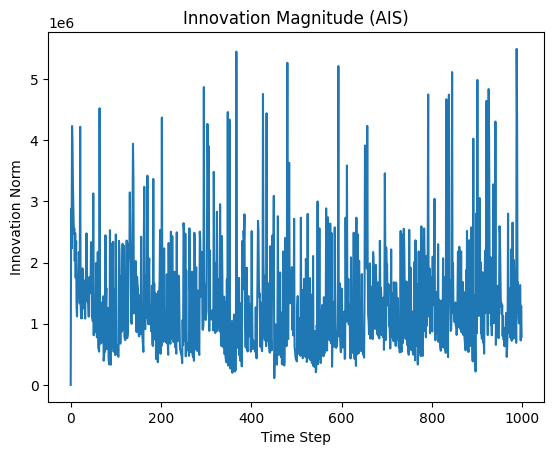

In [19]:
plt.figure()
plt.plot(np.linalg.norm(innovations,axis=1))
plt.title('Innovation Magnitude (AIS)')
plt.xlabel('Time Step')
plt.ylabel('Innovation Norm')
plt.show()

## NIS Plot

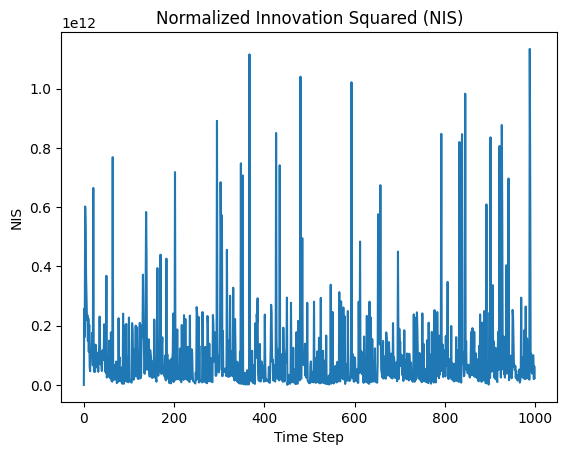

In [20]:
plt.figure()
plt.plot(nis_values)
plt.title('Normalized Innovation Squared (NIS)')
plt.xlabel('Time Step')
plt.ylabel('NIS')
plt.show()

## NIS Consistency Bounds (Chi-square, DOF=2)

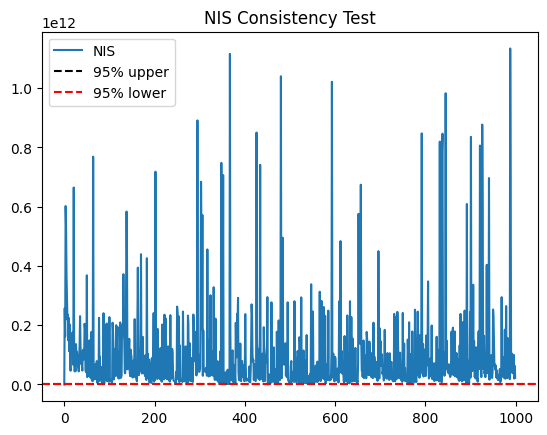

In [22]:
lower = 0.103
upper = 5.991

plt.figure()
plt.plot(nis_values,label='NIS')
plt.axhline(upper,linestyle='--',color='black',label='95% upper')
plt.axhline(lower,linestyle='--',color='red',label='95% lower')
plt.legend()
plt.title('NIS Consistency Test')
plt.show()